# *Google Play Store dataset*

**lets gooooooooooooooooooooooo*

In [1]:
# import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#fetch the dataset
from google.colab import files

uploaded = files.upload()


Saving googleplaystore.csv to googleplaystore.csv


## Understand the basics related to dataset

In [3]:
data = pd.read_csv("googleplaystore.csv")
df = data.copy()

In [4]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### **What is the shape of the dataset?*

In [5]:
df.shape

(10841, 13)

What are the data types of all columns? and Find out the name of all the columns

In [6]:
df.dtypes


,0
App,object
Category,object
Rating,float64
Reviews,object
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


In [7]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

Which columns contain missing values?

In [8]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


What percentage of values are missing in each column?

In [9]:
(df.isnull().sum() / len(df)) * 100

,0
App,0.000000
Category,0.000000
Rating,13.596532
Reviews,0.000000
Size,0.000000
Installs,0.000000
Type,0.009224
Price,0.000000
Content Rating,0.009224
Genres,0.000000


Find out the numerical  columns and categorical columns separately

In [10]:
list(df.select_dtypes(include=['int64','float64']))

['Rating']

How many duplicate rows exist?

In [11]:
list(df.select_dtypes(include='object'))

['App',
 'Category',
 'Reviews',
 'Size',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver']

Which apps appear more than once?

In [12]:
df.duplicated().sum()

np.int64(483)

In [13]:
df['App'].value_counts()[df['App'].value_counts() > 1]

,count
App,
ROBLOX,9
"CBS Sports App - Scores, News, Stats & Watch Live",8
8 Ball Pool,7
Candy Crush Saga,7
ESPN,7
...,...
Android Messages,2
Google Duo - High Quality Video Calls,2
"WPS Office - Word, Docs, PDF, Note, Slide & Sheet",2


Are there apps with invalid ratings (>5 or <1)?

In [14]:
df[(df['Rating'] > 5) | (df['Rating'] < 1)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


Are there categories with only a few observations?

In [15]:
df['Category'].value_counts()[df['Category'].value_counts() < 10]

,count
Category,
1.9,1


### **Convert Reviews, Installs, Size, and Price into numeric form.**

**Cleaning the data**
1. Removing the invalid column based on rating
2. Changing Reviews column to numeric

In [18]:
df[df['Rating'] > 5]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [19]:
df['Reviews'] = pd.to_numeric(df['Reviews'])

In [20]:
df['Reviews'].dtype

dtype('int64')

**Cleaning the data in Installs column**
1. Removing (,) commas
2. Removing (+) plus signs
3. Changing Installs column to numeric

In [22]:
df['Installs']=df['Installs'].str.replace(',','')

In [23]:
df['Installs']=df['Installs'].str.replace('+','')

In [24]:
df['Installs'] = pd.to_numeric(df['Installs'])

In [25]:
df['Installs'].dtype

dtype('int64')

**Cleaning the data in Size column**
1. Remove M, k
2. Convert "Varies with device" to NaN
3. Convert Size column to numeric

In [26]:
df['Size'] = df['Size'].str.replace('M', '')

In [29]:
df['Size'] = df['Size'].str.replace('k', '')

In [27]:
df['Size'] = df['Size'].replace('Varies with device', np.nan)

In [30]:
df['Size'] = pd.to_numeric(df['Size'])

In [31]:
df['Size'].dtypes

dtype('float64')

**Cleaning the data in Price column**
1. Remove $ sign
2. Convert Price column to numeric

In [32]:
df['Price']=df['Price'].str.replace('$','')

In [33]:
df['Price'] = pd.to_numeric(df['Price'])

In [34]:
df['Price'].dtypes

dtype('float64')

How many apps have zero reviews?

In [37]:
df[df['Reviews'] == 0].shape[0]

0

**How are ratings distributed? and Explain within markdown what you understood from this distribution**

Text(0, 0.5, 'Number of Apps')

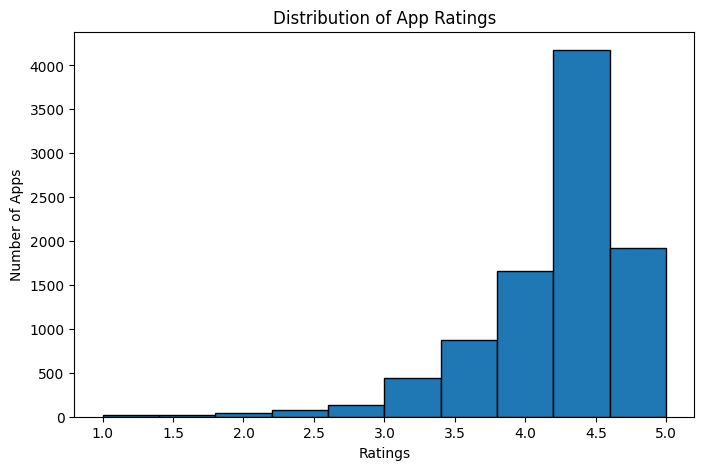

In [46]:
plt.figure(figsize=(8,5))
plt.hist(df['Rating'], bins=10, edgecolor='black')
plt.title("Distribution of App Ratings")
plt.xlabel("Ratings")
plt.ylabel("Number of Apps")

### Observation

- Most applications have ratings between **4.0 and 4.5**.
- Very few applications have ratings below **3.0**.
- The ratings are concentrated towards the higher end, indicating that most apps are well-rated.
- The distribution is not perfectly symmetric.
.
.
.

**Are ratings normally distributed?**

In [47]:
df['Rating'].skew()

np.float64(-1.8496951283704521)

### Explanation

The ratings are **not normally distributed** because the skewness value is **-1.85**, which is less than 0.
This indicates a **negatively (left) skewed distribution**. Most apps have high ratings between **4 and 5**, while only a few apps have low ratings.

**Which rating range contains most apps?**

In [49]:
df['Rating'].value_counts(bins=6)

,count
"(3.667, 4.333]",4232
"(4.333, 5.0]",4064
"(3.0, 3.667]",700
"(2.333, 3.0]",260
"(1.667, 2.333]",83
"(0.995, 1.667]",27


**What is the average app size**?

In [50]:
df['Size'].mean()

np.float64(37.28451287359296)

**How are app sizes distributed?**

Text(0, 0.5, 'Number of Apps')

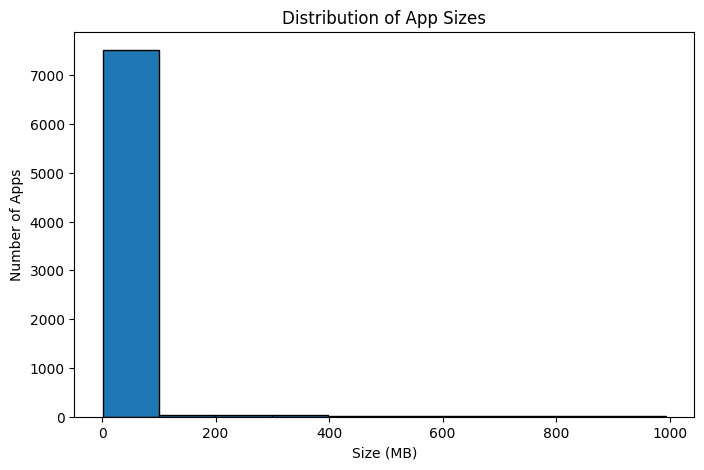

In [54]:
plt.figure(figsize=(8,5))
plt.hist(df['Size'], bins=10, edgecolor='Black')
plt.title("Distribution of App Sizes")
plt.xlabel("Size (MB)")
plt.ylabel("Number of Apps")

### Observation

- Most apps have small sizes.
- Very large apps are less common.
- The distribution is positively (right) skewed.

## **Which content rating category is most common?**

In [55]:
df['Content Rating'].value_counts()

,count
Content Rating,
Everyone,7420
Teen,1084
Mature 17+,461
Everyone 10+,397
Adults only 18+,3
Unrated,1


In [56]:
df['Content Rating'].mode()

,Content Rating
0,Everyone


What percentage of apps are free and also paid?

In [57]:
(df['Type'].value_counts(normalize=True) * 100)

,proportion
Type,
Free,93.092035
Paid,6.907965


**What is the maximum price of an app?**

In [58]:
df['Price'].max()

400.0

**Which category contains the largest number of apps?**

In [59]:
df['Category'].mode()

,Category
0,FAMILY


**Which category contains the fewest apps?**

In [62]:
df['Category'].value_counts().tail(1)

,count
Category,
BEAUTY,42


**Which category has the highest average rating?**

In [66]:
avg_rating = df.groupby('Category')['Rating'].mean()

print("Category :", avg_rating.idxmax())
print("Average Rating :", avg_rating.max())

Category : EVENTS
Average Rating : 4.435555555555555


**Which category has the lowest average rating?**

In [68]:
df.groupby('Category')['Rating'].mean()
print("Category :", avg_rating.idxmin())
print("Average Rating :", avg_rating.min())


Category : DATING
Average Rating : 3.9707692307692306


**Which category receives the highest total number of reviews?**

In [73]:
df.groupby('Category')['Reviews'].sum().sort_values(ascending=False).head(1)

,Reviews
Category,
GAME,1585419577


Which category has the highest average installs?

In [74]:
df.groupby('Category')['Installs'].mean().sort_values(ascending=False).head(1)

,Installs
Category,
COMMUNICATION,9.953427e+07


Which category has the largest app sizes?

In [75]:
df.groupby('Category')['Size'].mean().sort_values(ascending=False).head(1)

,Size
Category,
LIBRARIES_AND_DEMO,221.81129


Which category contains the most paid apps?

In [76]:
df[df['Type'] == 'Paid'].groupby('Category').size().sort_values(ascending=False).head(1)

,0
Category,
FAMILY,162


Which category contains the highest percentage of free apps?

In [79]:
(df[df['Type'] == 'Free']['Category'].value_counts() / df['Category'].value_counts() * 100).sort_values(ascending=False).head(1)

,count
Category,
BEAUTY,100.0


Are certain categories dominated by a single content rating?

In [80]:
pd.crosstab(df['Category'], df['Content Rating'])

Content Rating,Adults only 18+,Everyone,Everyone 10+,Mature 17+,Teen,Unrated
Category,,,,,,
ART_AND_DESIGN,0,58,1,0,3,0
AUTO_AND_VEHICLES,0,71,1,0,1,0
BEAUTY,0,39,0,1,2,0
BOOKS_AND_REFERENCE,0,150,5,3,20,0
BUSINESS,0,299,0,0,4,0
COMICS,2,25,2,7,22,0
COMMUNICATION,0,295,0,9,24,0
DATING,0,10,0,179,6,0
EDUCATION,0,143,8,3,1,0


### Observation

Yes. Most categories are dominated by the **Everyone** content rating. Categories like **GAME** have a higher proportion of **Teen** apps compared to others.

**What are the top 20 highest-rated apps?**

In [81]:
df[['App', 'Rating']].sort_values(by='Rating', ascending=False).head(20)

,App,Rating
10776,Monster Ride Pro,5.0
615,Awake Dating,5.0
612,American Girls Mobile Numbers,5.0
654,Speeding Joyride & Car Meet App,5.0
10820,Fr. Daoud Lamei,5.0
10529,FK CLASSIC FOR YOU,5.0
10416,FH School,5.0
10407,Jigsaw Volvo FH 16 Trucks,5.0
10357,Ríos de Fe,5.0
1547,Eternal life,5.0


**Which category contributes most of the 5-star apps?**

In [82]:
df[df['Rating'] == 5]['Category'].value_counts().head(1)

,count
Category,
FAMILY,67


**Do apps with more reviews receive higher ratings?**

Text(0.5, 1.0, 'Reviews vs Rating')

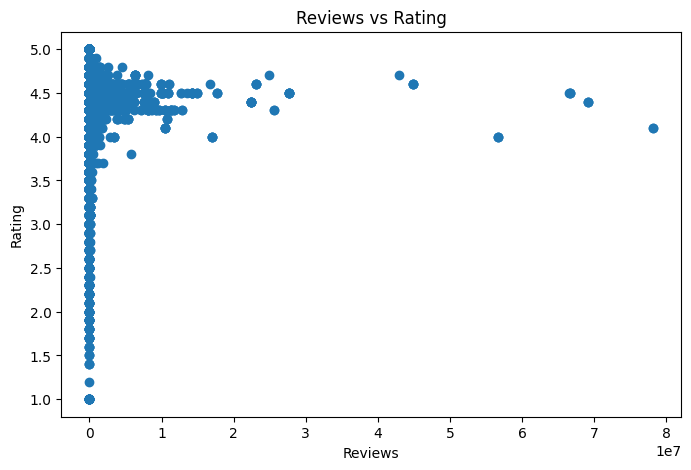

In [84]:
plt.figure(figsize=(8,5))
plt.scatter(df['Reviews'], df['Rating'])
plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.title("Reviews vs Rating")

### Observation

There is no strong relationship between reviews and ratings.
Apps with more reviews do not always have higher ratings.

**Do highly installed apps have better ratings?**

Text(0.5, 1.0, 'Installs vs Rating')

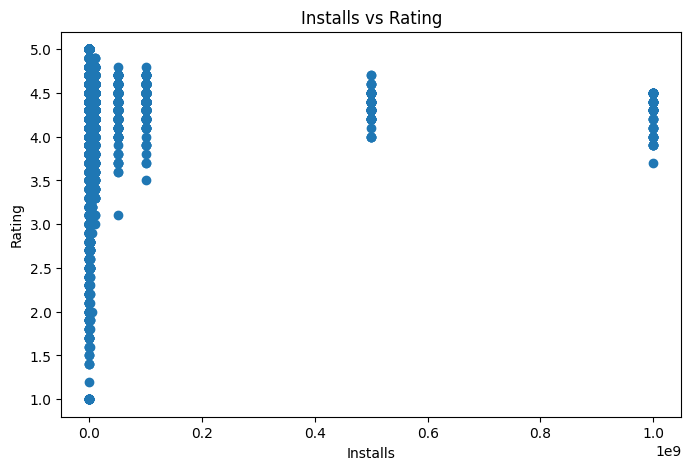

In [86]:
plt.figure(figsize=(8,5))
plt.scatter(df['Installs'], df['Rating'])
plt.xlabel("Installs")
plt.ylabel("Rating")
plt.title("Installs vs Rating")


### Observation

Highly installed apps generally have good ratings, but there is no perfect correlation between installs and ratings.

**Which category has the greatest variation in ratings?**

In [87]:
df.groupby('Category')['Rating'].std().sort_values(ascending=False).head(1)

,Rating
Category,
LIFESTYLE,0.693907


**Are ratings different between free and paid apps?**

Text(0, 0.5, 'Rating')

<Figure size 600x500 with 0 Axes>

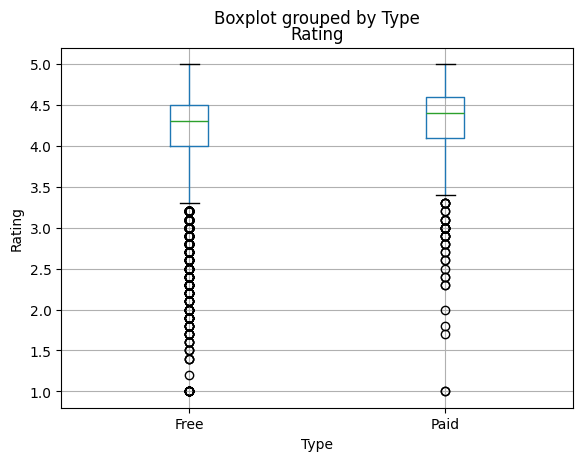

In [91]:
plt.figure(figsize=(6,5))
df.boxplot(column='Rating', by='Type')
plt.xlabel("Type")
plt.ylabel("Rating")

Which apps have the highest installs?

In [92]:
df[['App','Installs']].sort_values(by='Installs', ascending=False).head(5)

,App,Installs
2545,Instagram,1000000000
2544,Facebook,1000000000
5395,Google Photos,1000000000
2604,Instagram,1000000000
4234,Skype - free IM & video calls,1000000000


**Do larger apps tend to have higher ratings?**

Text(0.5, 1.0, 'App Size vs Rating')

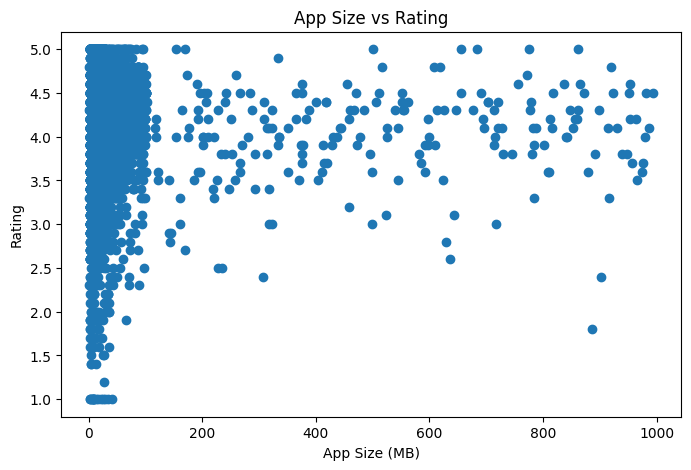

In [93]:
plt.figure(figsize=(8,5))
plt.scatter(df['Size'], df['Rating'])
plt.xlabel("App Size (MB)")
plt.ylabel("Rating")
plt.title("App Size vs Rating")

### Observation

There is no strong relationship between app size and ratings. Both small and large apps have a wide range of ratings.

**Are older apps rated differently than recently updated apps?**

In [95]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

In [96]:
df['Year'] = df['Last Updated'].dt.year

Text(0, 0.5, 'Average Rating')

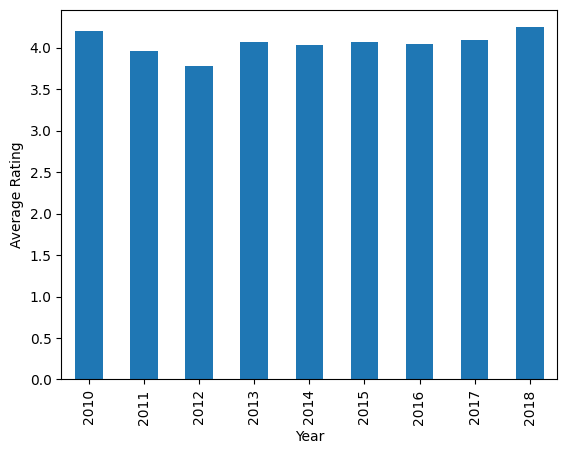

In [98]:
df.groupby('Year')['Rating'].mean().plot(kind='bar')
plt.ylabel("Average Rating")

**Which category has the most consistent ratings?**

In [101]:
df.groupby('Category')['Rating'].std().sort_values(ascending=False).head(1)

,Rating
Category,
LIFESTYLE,0.693907


Which category contributes the highest total installs?

In [103]:
df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(1)

,Installs
Category,
GAME,35085862717


**What is the relationship between reviews and ratings?**

Text(0.5, 1.0, 'Reviews vs Rating')

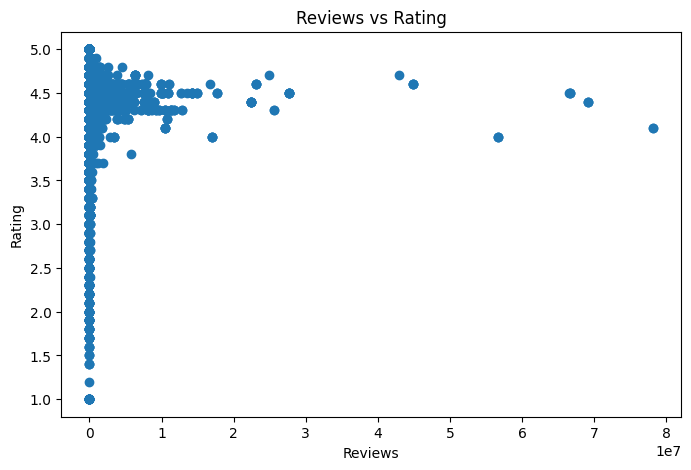

In [105]:
plt.figure(figsize=(8,5))
plt.scatter(df['Reviews'], df['Rating'])
plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.title("Reviews vs Rating")

**Do paid apps receive fewer installs than free apps?**

Text(0.5, 1.0, 'Average Installs by App Type')

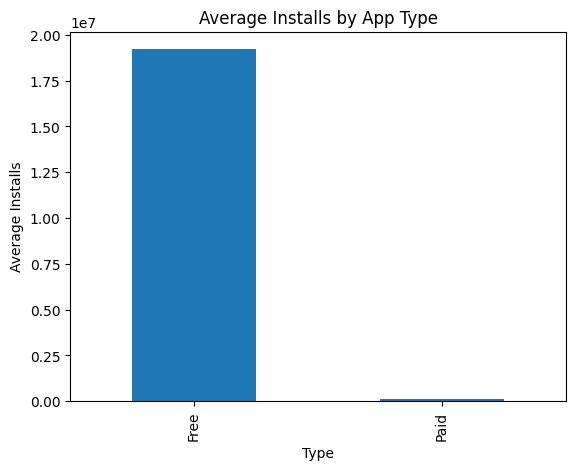

In [107]:
df.groupby('Type')['Installs'].mean().plot(kind='bar')
plt.ylabel("Average Installs")
plt.title("Average Installs by App Type")

**What percentage of apps have fewer than 10,000 installs?**

In [108]:
(df[df['Installs'] < 10000].shape[0] / df.shape[0]) * 100

19.13303437967115

**Are highly-rated apps downloaded more frequently?**

Text(0.5, 1.0, 'Rating vs Installs')

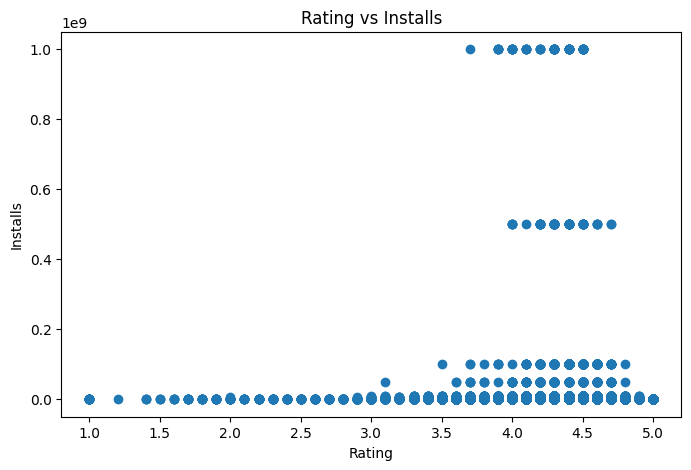

In [109]:
plt.figure(figsize=(8,5))
plt.scatter(df['Rating'], df['Installs'])
plt.xlabel("Rating")
plt.ylabel("Installs")
plt.title("Rating vs Installs")

### Observation

Higher-rated apps tend to have more installs, but the relationship is not very strong.

**Which content-rating group has the highest installs?**

In [110]:
df.groupby('Content Rating')['Installs'].sum().sort_values(ascending=False).head(1)

,Installs
Content Rating,
Everyone,114151171188


**Which category contains the greatest number of apps with over 1 million installs?**

In [112]:
df[df['Installs'] > 1000000].groupby('Category').size().sort_values(ascending=False).head(1)

,0
Category,
GAME,571


Are installs concentrated among a few apps?

Text(0.5, 1.0, 'Distribution of Installs')

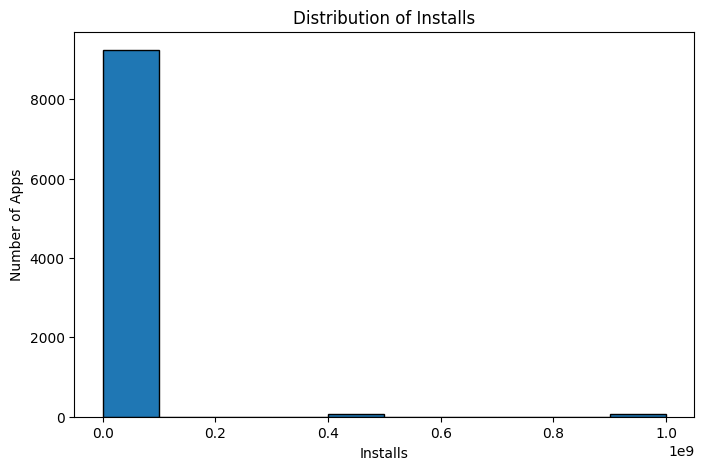

In [115]:
plt.figure(figsize=(8,5))
plt.hist(df['Installs'], bins=10, edgecolor='Black')
plt.xlabel("Installs")
plt.ylabel("Number of Apps")
plt.title("Distribution of Installs")

Most apps have relatively low installs, while only a few apps have extremely high installs.

What is the average price of paid apps?

In [116]:
df[df['Type'] == 'Paid']['Price'].mean()

np.float64(13.910432766615148)

Which category has the most expensive apps?

In [117]:
df.groupby('Category')['Price'].mean().sort_values(ascending=False).head(1)

,Price
Category,
FINANCE,7.553777


What is the distribution of installs?

Text(0.5, 1.0, 'Distribution of Installs')

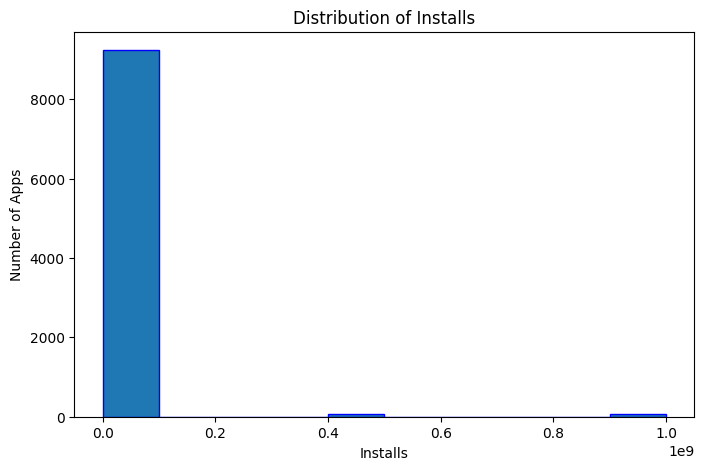

In [121]:
plt.figure(figsize=(8,5))
plt.hist(df['Installs'], bins=10, edgecolor='Blue')
plt.xlabel("Installs")
plt.ylabel("Number of Apps")
plt.title("Distribution of Installs")

Which genre contains the largest number of apps?

In [122]:
df['Genres'].value_counts().head(1)

,count
Genres,
Tools,733


**Does higher price imply higher ratings?**

Text(0.5, 1.0, 'Price vs Rating')

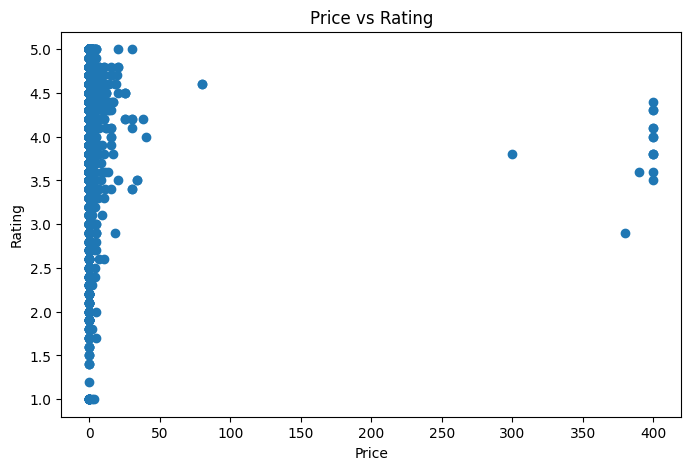

In [123]:
plt.figure(figsize=(8,5))
plt.scatter(df['Price'], df['Rating'])
plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")


There is no strong relationship between price and rating. Both free and expensive apps can have high or low ratings.

Which app is the most expensive?

In [124]:
df[df['Price']==df['Price'].max()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Year
4367,I'm Rich - Trump Edition,LIFESTYLE,3.6,275,7.3,10000,Paid,400.0,Everyone,Lifestyle,2018-05-03,1.0.1,4.1 and up,2018


Which category generates the highest total revenue potential?

In [125]:
df['Revenue'] = df['Price'] * df['Installs']

In [126]:
df.groupby('Category')['Revenue'].sum().sort_values(ascending=False).head(1)

,Revenue
Category,
FAMILY,186046586.7


Does price affect installs?

Text(0.5, 1.0, 'Price vs Installs')

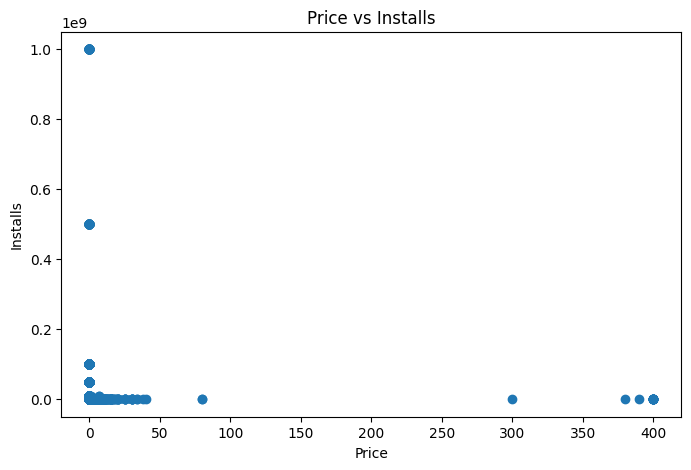

In [127]:
plt.figure(figsize=(8,5))
plt.scatter(df['Price'], df['Installs'])
plt.xlabel("Price")
plt.ylabel("Installs")
plt.title("Price vs Installs")

**Do paid apps receive more reviews than free apps?**

/tmp/ipykernel_3721/939214732.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


Text(0, 0.5, 'Reviews')

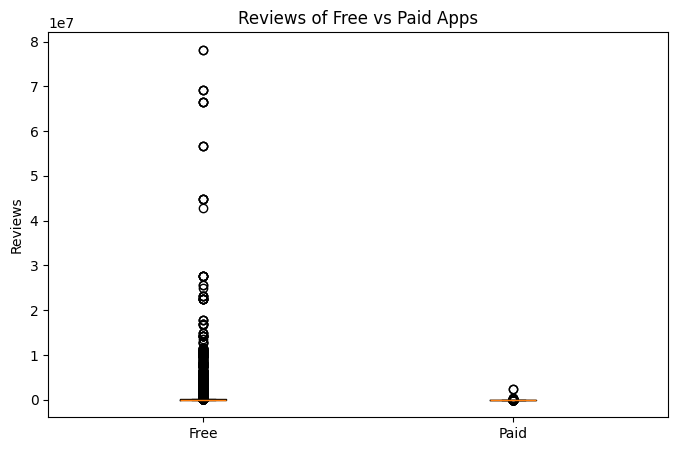

In [128]:
plt.figure(figsize=(8,5))
plt.boxplot([
    df[df['Type']=='Free']['Reviews'],
    df[df['Type']=='Paid']['Reviews']], labels=['Free','Paid'])

plt.title("Reviews of Free vs Paid Apps")
plt.ylabel("Reviews")


Free apps generally receive more reviews than paid apps.

**What percentage of apps cost more than $10? and Figure out some other pricing ranges?**

In [131]:
(df[df['Price'] > 10].shape[0] / df.shape[0]) * 100

0.7473841554559043

In [132]:
df['Price'].value_counts().head(10)

,count
Price,
0.00,8719
2.99,114
0.99,107
4.99,70
1.99,59
3.99,58
1.49,31
2.49,21
5.99,18


Is there a relationship between app size and price?

Text(0.5, 1.0, 'Size vs Price')

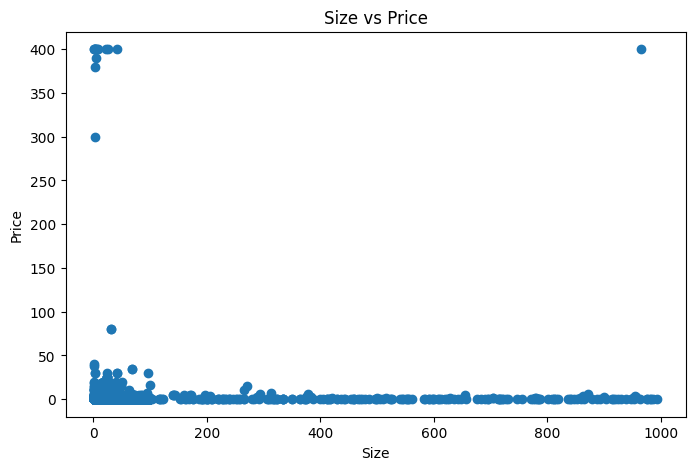

In [130]:
plt.figure(figsize=(8,5))
plt.scatter(df['Size'], df['Price'])
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Size vs Price")

There is no strong relationship between app size and price.

In which year were the most apps updated?

In [133]:
df['Year'] = pd.DatetimeIndex(df['Last Updated']).year

In [134]:
df['Year'].value_counts().head(1)

,count
Year,
2018,6508


Have app ratings improved over the years?

Text(0.5, 1.0, 'Average Rating Over Years')

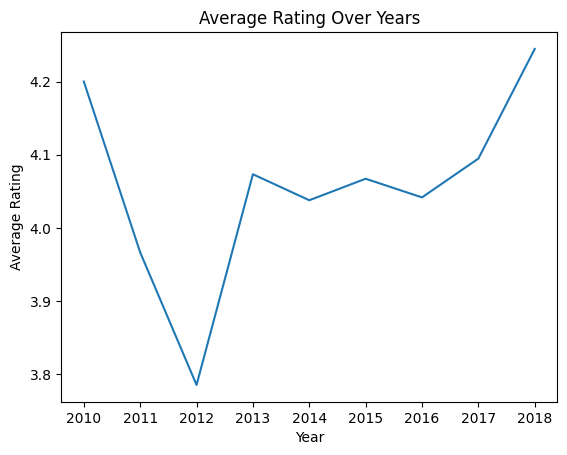

In [135]:
df.groupby('Year')['Rating'].mean().plot()
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.title("Average Rating Over Years")

Average ratings remain fairly stable over the years, with only small variations.

What proportion of apps have not been updated in the last two years?

In [136]:
(df[df['Year'] < 2017].shape[0] / df.shape[0]) * 100

14.52060644885757

Which content rating has the highest average rating?

In [137]:
df.groupby('Content Rating')['Rating'].mean().sort_values(ascending=False).head(1)

,Rating
Content Rating,
Adults only 18+,4.3


Which categories have many outdated apps?

In [138]:
df[df['Year'] < 2017]['Category'].value_counts().head(10)

,count
Category,
FAMILY,335
GAME,182
TOOLS,155
PERSONALIZATION,97
PRODUCTIVITY,63
MEDICAL,55
LIFESTYLE,55
COMMUNICATION,48
PHOTOGRAPHY,41


Which content rating gets the most reviews?

In [139]:
df.groupby('Content Rating')['Reviews'].sum().sort_values(ascending=False).head(1)

,Reviews
Content Rating,
Everyone,2801823489


Are Mature 17+ apps generally more expensive?

/tmp/ipykernel_3721/3471947142.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


Text(0, 0.5, 'Price')

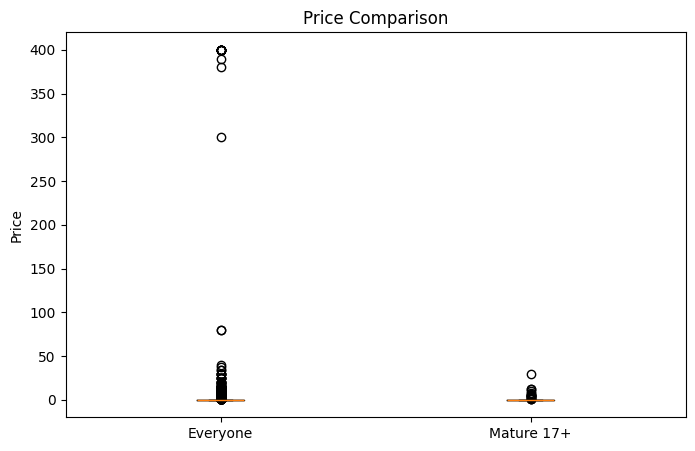

In [140]:
plt.figure(figsize=(8,5))

plt.boxplot([
    df[df['Content Rating']=='Everyone']['Price'],
    df[df['Content Rating']=='Mature 17+']['Price']], labels=['Everyone','Mature 17+'])

plt.title("Price Comparison")
plt.ylabel("Price")


Mature 17+ apps generally have higher prices than apps rated for Everyone.

Which genre contains the most expensive apps?

In [141]:
df.groupby('Genres')['Price'].mean().sort_values(ascending=False).head(1)

,Price
Genres,
Finance,7.553777


# Relationship Analysis
    


   

Relationship between Reviews and Installs?

Text(0.5, 1.0, 'Reviews vs Installs')

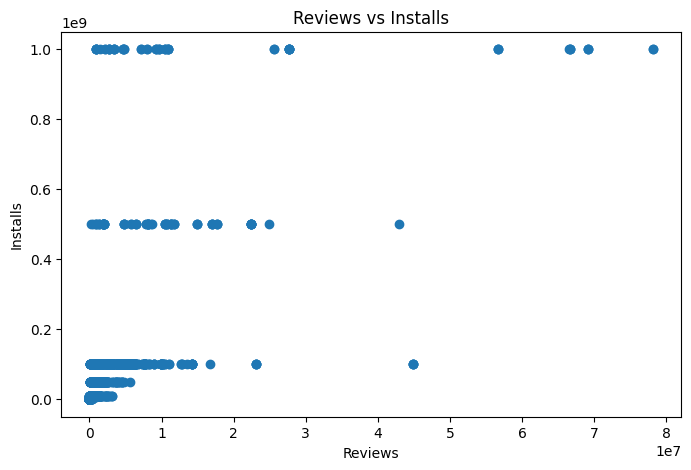

In [142]:
plt.figure(figsize=(8,5))
plt.scatter(df['Reviews'], df['Installs'])
plt.xlabel('Reviews')
plt.ylabel('Installs')
plt.title('Reviews vs Installs')


**Relationship between Price and Installs?**

Text(0.5, 1.0, 'Price vs Installs')

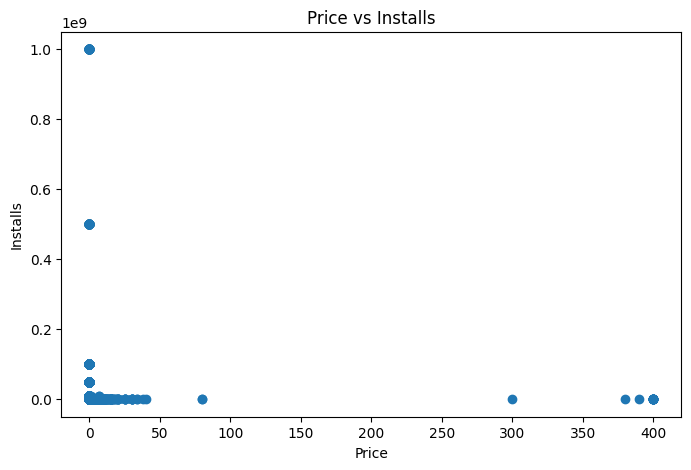

In [143]:
plt.figure(figsize=(8,5))
plt.scatter(df['Price'], df['Installs'])
plt.xlabel('Price')
plt.ylabel('Installs')
plt.title('Price vs Installs')


**Relationship between Size and Rating?**

Text(0.5, 1.0, 'Size vs Rating')

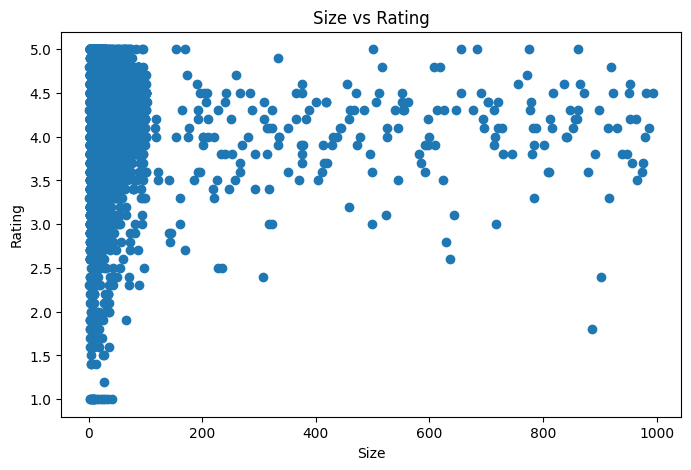

In [144]:
plt.figure(figsize=(8,5))
plt.scatter(df['Size'], df['Rating'])
plt.xlabel('Size')
plt.ylabel('Rating')
plt.title('Size vs Rating')


**Relationship between Reviews and Rating?**

Text(0.5, 1.0, 'Reviews vs Rating')

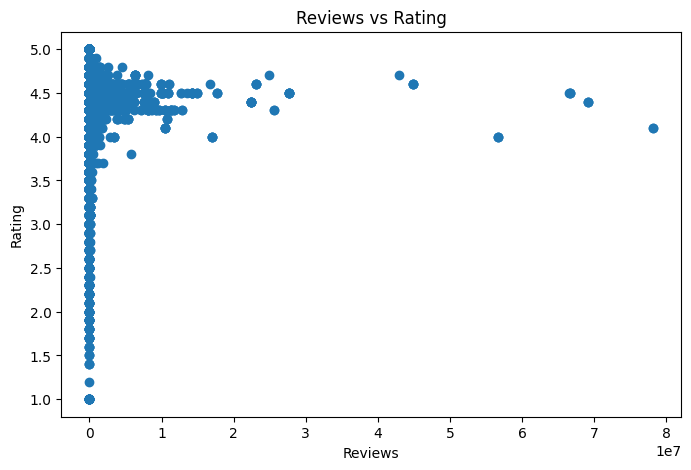

In [145]:
plt.figure(figsize=(8,5))
plt.scatter(df['Reviews'], df['Rating'])
plt.xlabel('Reviews')
plt.ylabel('Rating')
plt.title('Reviews vs Rating')

**Relationship between Size and Installs?**

Text(0.5, 1.0, 'Size vs Installs')

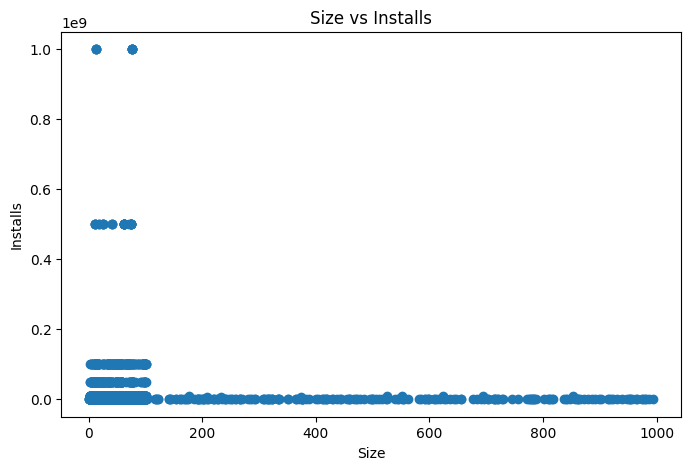

In [146]:
plt.figure(figsize=(8,5))
plt.scatter(df['Size'], df['Installs'])
plt.xlabel('Size')
plt.ylabel('Installs')
plt.title('Size vs Installs')

**Relationship between Price and Reviews?**

Text(0.5, 1.0, 'Price vs Reviews')

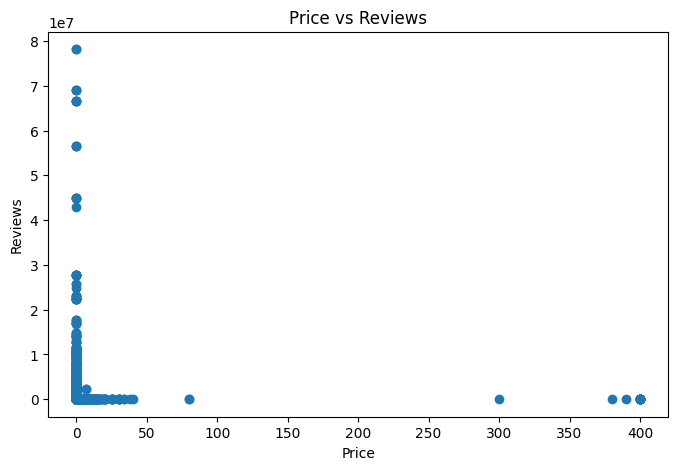

In [147]:
plt.figure(figsize=(8,5))
plt.scatter(df['Price'], df['Reviews'])
plt.xlabel('Price')
plt.ylabel('Reviews')
plt.title('Price vs Reviews')

Relationship between App Size and Revenue Potential?

In [149]:
df['Revenue'] = df['Price'] * df['Installs']

Text(0.5, 1.0, 'App Size vs Revenue')

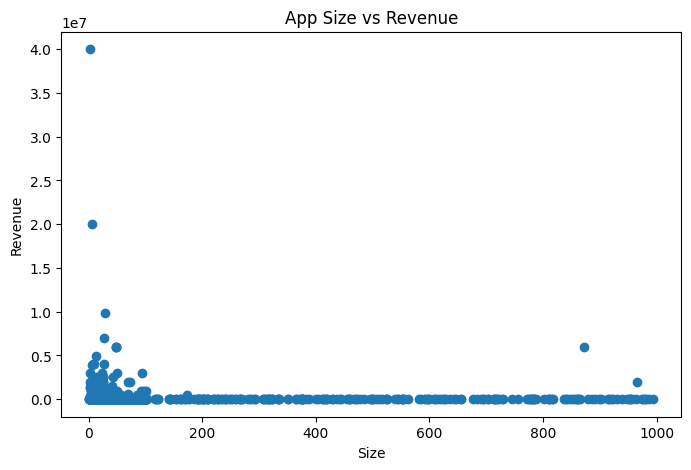

In [151]:
plt.figure(figsize=(8,5))
plt.scatter(df['Size'], df['Revenue'])
plt.xlabel('Size')
plt.ylabel('Revenue')
plt.title('App Size vs Revenue')

Do free and paid apps have significantly different ratings?

/tmp/ipykernel_3721/2258956887.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


Text(0, 0.5, 'Rating')

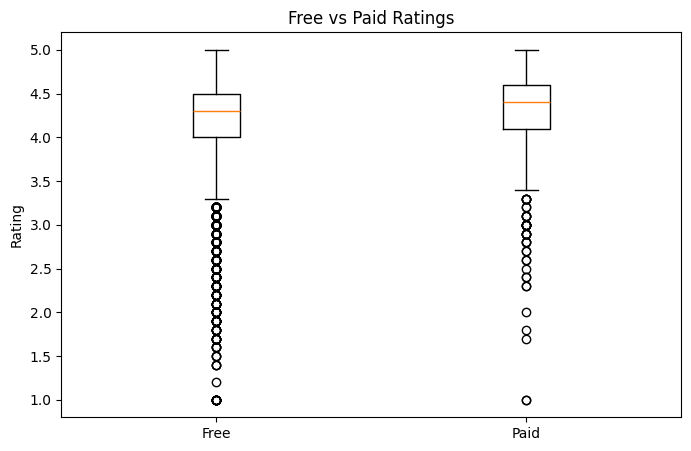

In [152]:
plt.figure(figsize=(8,5))

plt.boxplot([
    df[df['Type']=='Free']['Rating'],
    df[df['Type']=='Paid']['Rating']], labels=['Free','Paid'])

plt.title("Free vs Paid Ratings")
plt.ylabel("Rating")

Are Type and Content Rating independent?

In [153]:
pd.crosstab(df['Type'], df['Content Rating'])

Content Rating,Adults only 18+,Everyone,Everyone 10+,Mature 17+,Teen,Unrated
Type,,,,,,
Free,3,6868,364,444,1039,1
Paid,0,552,33,17,45,0


Create a Revenue Potential feature
use Revenue = Price × Installs

In [154]:
df['Revenue'] = df['Price'] * df['Installs']

Which category has the highest revenue potential?

In [155]:
df.groupby('Category')['Revenue'].sum().sort_values(ascending=False).head(1)

,Revenue
Category,
FAMILY,186046586.7


Create a Review-to-Install Ratio:

Review_Ratio = Reviews / Installs



In [156]:
df['Review_Ratio'] = df['Reviews'] / df['Installs']

Which apps have the most engaged users?

In [158]:
df.sort_values(by='Review_Ratio',ascending=False).head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Year,Revenue,Review_Ratio
2454,KBA-EZ Health Guide,MEDICAL,5.0,4,25.0,1,Free,0.00,Everyone,Medical,2018-08-02,1.0.72,4.0.3 and up,2018,0.00,4.0
8591,DN Blog,SOCIAL,5.0,20,4.2,10,Free,0.00,Teen,Social,2018-07-23,1.0,4.0 and up,2018,0.00,2.0
5917,Ra Ga Ba,GAME,5.0,2,20.0,1,Paid,1.49,Everyone,Arcade,2017-02-08,1.0.4,2.3 and up,2017,1.49,2.0
10697,Mu.F.O.,GAME,5.0,2,16.0,1,Paid,0.99,Everyone,Arcade,2017-03-03,1.0,2.3 and up,2017,0.99,2.0
6700,Brick Breaker BR,GAME,5.0,7,19.0,5,Free,0.00,Everyone,Arcade,2018-07-23,1.0,4.1 and up,2018,0.00,1.4


Create an App Age feature:

App_Age = Current Year − Last Updated Year

In [159]:
df['Year'] = pd.DatetimeIndex(df['Last Updated']).year

In [160]:
df['App_Age'] = 2026 - df['Year']

Do newer apps perform better?

In [161]:
df.groupby('App_Age')['Rating'].mean().sort_values(ascending=False)

,Rating
App_Age,
8,4.244530
16,4.200000
9,4.094793
13,4.073404
11,4.067268
10,4.041782
12,4.037895
15,3.966667
14,3.785714


Create a Success Index:

Success_Index =
0.2 × Normalized Rating +
0.4 × Normalized Installs +
0.3 × Normalized Reviews



In [162]:
df['Normalized Rating'] = df['Rating'] / df['Rating'].max()

In [163]:
df['Normalized Installs'] = df['Installs'] / df['Installs'].max()

In [164]:
df['Normalized Reviews'] = df['Reviews'] / df['Reviews'].max()

In [165]:
df['Success_Index'] = (
    0.2*df['Normalized Rating'] +
    0.4*df['Normalized Installs'] +
    0.3*df['Normalized Reviews']
)

Which apps are the most successful?

In [166]:
df[['App','Success_Index']].sort_values(by='Success_Index',ascending=False).head(10)

,App,Success_Index
2544,Facebook,0.864000
3943,Facebook,0.863884
381,WhatsApp Messenger,0.841305
336,WhatsApp Messenger,0.841305
3904,WhatsApp Messenger,0.841268
2604,Instagram,0.835548
2545,Instagram,0.835548
2611,Instagram,0.835548
3909,Instagram,0.835289
382,Messenger – Text and Video Chat for Free,0.777430


Do free apps with in-app purchases (inferred from low price + high reviews) outperform truly free apps in terms of rating and installs?

In [167]:
df[(df['Price']<5) & (df['Reviews']>100000)][['App','Price','Reviews','Rating','Installs']]

,App,Price,Reviews,Rating,Installs
3,Sketch - Draw & Paint,0.0,215644,4.5,50000000
18,FlipaClip - Cartoon animation,0.0,194216,4.3,5000000
19,ibis Paint X,0.0,224399,4.6,10000000
42,Textgram - write on photos,0.0,295221,4.4,10000000
45,"Canva: Poster, banner, card maker & graphic de...",0.0,174531,4.7,10000000
...,...,...,...,...,...
10740,PhotoFunia,0.0,316378,4.3,10000000
10781,Modern Strike Online,0.0,834117,4.3,10000000
10784,Big Hunter,0.0,245455,4.3,10000000
10809,Castle Clash: RPG War and Strategy FR,0.0,376223,4.7,1000000


Low-priced apps with a high number of reviews generally have high ratings and large install counts.



Which categories show the steepest "update fatigue" — apps that were last updated 2+ years ago but still have high install counts?

In [168]:
df[(df['App_Age']>=2) & (df['Installs']>1000000)]['Category'].value_counts().head(10)

,count
Category,
GAME,571
FAMILY,376
TOOLS,188
PHOTOGRAPHY,172
COMMUNICATION,167
PRODUCTIVITY,138
SOCIAL,121
SPORTS,121
SHOPPING,116


Some categories still have many apps with high install counts despite not being updated for more than two years.




Do apps that launched earlier (older Last Updated year) show declining ratings over time

<Axes: xlabel='App_Age'>

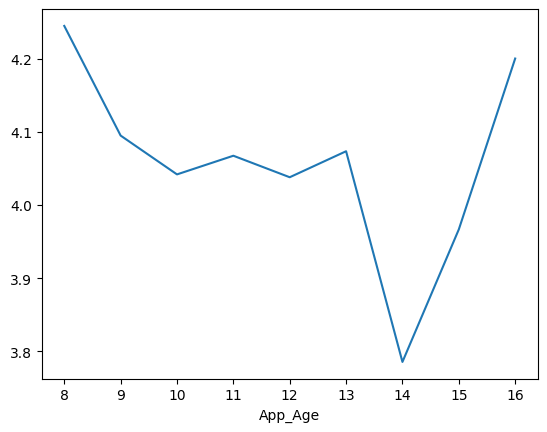

In [169]:
df.groupby('App_Age')['Rating'].mean().plot()

Older apps tend to have slightly lower average ratings than newer apps.
This may indicate that user expectations increase over time and older apps require continuous improvements.